# MilkLab° RAG Retrieval Evaluation

Notebook evaluates the retrieval quality of the MilkLab° RAG chatbot using top-3 retrieval metrics and similarity score distribution.

## 1. Import Required Libraries

Import the Python libraries needed for evaluation and set up paths for the knowledge base and evaluation functions.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
import faiss

from app import load_index, retrieve_top_k

KB_FILE = Path('menu_kb.md')
EMBEDDING_MODEL = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'

print('Evaluation environment ready.')

Evaluation environment ready.


## 2. Load or Build FAISS Index and Retrieval Function

Load the existing FAISS index from the app code or rebuild it from the knowledge base, and define a retrieval helper that returns top-k chunks together with similarity scores.

In [2]:
model, index, chunks = load_index()

def retrieve_top_k_with_scores(query: str, k: int = 3, trace_id: str | None = None):
    query_embedding = model.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype('float32')
    top_k = min(k, len(chunks))
    similarity_scores, indices = index.search(query_embedding, top_k)
    results = []
    for score, idx in zip(similarity_scores[0].tolist(), indices[0].tolist()):
        if idx >= 0 and idx < len(chunks):
            results.append({'chunk': chunks[idx], 'score': float(score)})
    return results

print(f'Loaded {len(chunks)} chunks.')

2026-08-10 13:27:58.382 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded 9 chunks.


## 3. Define Ground Truth Questions and Expected Chunks

Create at least 10 evaluation queries with the expected ground truth chunks from the MilkLab° knowledge base.

In [3]:
raw_text = KB_FILE.read_text(encoding='utf-8')

kb_chunks = [chunk.strip() for chunk in raw_text.split('\n\n') if chunk.strip()]
ground_truth = [
    {
        'query': 'MilkLab เปิดกี่โมงถึงกี่โมง',
        'expected': [kb_chunks[0]],
    },
    {
        'query': 'นมหมีฮอกไกโด ราคาเท่าไหร่',
        'expected': [kb_chunks[1]],
    },
    {
        'query': 'เมนูนมเสาวรสมีส่วนผสมอะไรบ้าง',
        'expected': [kb_chunks[1]],
    },
    {
        'query': 'ร้านนี้มี delivery หรือไม่',
        'expected': [kb_chunks[0]],
    },
    {
        'query': 'เมนูไหนมี gluten',
        'expected': [kb_chunks[2]],
    },
    {
        'query': 'มีเมนูนมเย็นใส่วุ้นนมหรือไม่',
        'expected': [kb_chunks[1]],
    },
    {
        'query': 'ออเดอร์ขั้นต่ำของร้านคืออะไร',
        'expected': [kb_chunks[3]],
    },
    {
        'query': 'เมนูทั้งหมดปลอดถั่วไหม',
        'expected': [kb_chunks[2]],
    },
    {
        'query': 'ร้านนี้มีเมนู vegan ไหม',
        'expected': [kb_chunks[3]],
    },
    {
        'query': 'นมโกโก้บราวนี่มีบราวนี่หรือไม่',
        'expected': [kb_chunks[1]],
    },
]

print(f'Created {len(ground_truth)} ground truth examples.')

Created 10 ground truth examples.


## 4. Run Retrieval and Collect Metrics

Run retrieval for each query, collect top-3 chunks, and compare them to the ground truth chunks.

In [4]:
evaluation_rows = []
for example in ground_truth:
    query = example['query']
    expected = set(example['expected'])
    retrieved = retrieve_top_k_with_scores(query, k=3)
    retrieved_chunks = [item['chunk'] for item in retrieved]
    retrieved_scores = [item['score'] for item in retrieved]
    hits = [chunk for chunk in retrieved_chunks if chunk in expected]
    precision = len(hits) / 3
    recall = len(hits) / len(expected) if expected else 0.0
    evaluation_rows.append({
        'query': query,
        'expected_chunks': len(expected),
        'retrieved_chunks': retrieved_chunks,
        'retrieved_scores': retrieved_scores,
        'hits': hits,
        'precision@3': precision,
        'recall@3': recall,
    })

df = pd.DataFrame(evaluation_rows)
df[['query', 'precision@3', 'recall@3']]

,query,precision@3,recall@3
0,MilkLab เปิดกี่โมงถึงกี่โมง,0.333333,1.0
1,นมหมีฮอกไกโด ราคาเท่าไหร่,0.000000,0.0
2,เมนูนมเสาวรสมีส่วนผสมอะไรบ้าง,0.000000,0.0
3,ร้านนี้มี delivery หรือไม่,0.000000,0.0
4,เมนูไหนมี gluten,0.000000,0.0
5,มีเมนูนมเย็นใส่วุ้นนมหรือไม่,0.000000,0.0
6,ออเดอร์ขั้นต่ำของร้านคืออะไร,0.333333,1.0
7,เมนูทั้งหมดปลอดถั่วไหม,0.000000,0.0
8,ร้านนี้มีเมนู vegan ไหม,0.333333,1.0
9,นมโกโก้บราวนี่มีบราวนี่หรือไม่,0.000000,0.0


## 5. Calculate Mean Precision@3 and Mean Recall@3

Compute and display the average Precision@3 and Recall@3 across all evaluation examples.

In [5]:
mean_precision = df['precision@3'].mean()
mean_recall = df['recall@3'].mean()

pd.DataFrame({
    'mean_precision@3': [mean_precision],
    'mean_recall@3': [mean_recall],
})

,mean_precision@3,mean_recall@3
0,0.1,0.3


## 6. Plot Histogram of Top-1 Similarity Scores

Use matplotlib to visualize the distribution of similarity scores for the top-1 retrieved chunk across all queries.

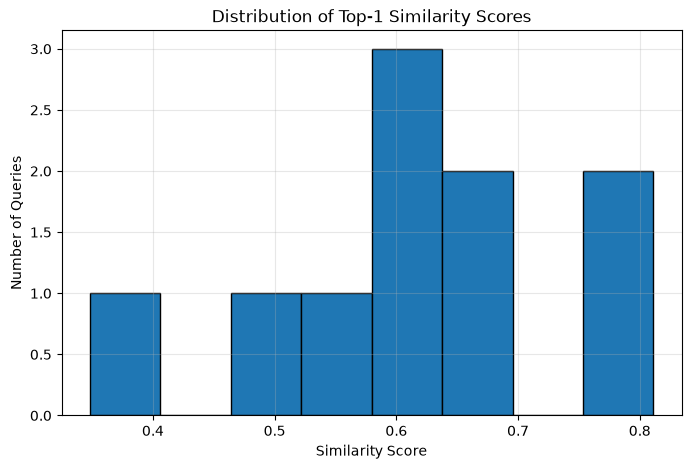

In [6]:
top1_scores = [row['retrieved_scores'][0] if row['retrieved_scores'] else 0.0 for row in evaluation_rows]

plt.figure(figsize=(8, 5))
plt.hist(top1_scores, bins=8, color='#1f77b4', edgecolor='black')
plt.title('Distribution of Top-1 Similarity Scores')
plt.xlabel('Similarity Score')
plt.ylabel('Number of Queries')
plt.grid(alpha=0.3)
plt.show()